 ## 1. Load Data

In [2]:
import pandas as pd
import gzip
import ujson

def load_jsonl_gz(path):
    rows = []
    with gzip.open(path, "rt") as f:
        for line in f:
            d = ujson.loads(line)
            base = {"backend": d["backend"], "scrape_time": d["scrape_time"]}
            if "qubit" in d :
                row = base | {"qubit": d["qubit"]} | d["properties"]
            else:
                row = base | {"gate": d["gate"], "qubits": tuple(d["qubits"])} | d["properties"]
            rows.append(row)
    df = pd.json_normalize(rows)
    df['scrape_time'] = pd.to_datetime(df['scrape_time'], format="%Y-%m-%d_%H-%M-%S",utc=True)
    if 'qubit' in df.columns:
        df['entity'] = df['backend'] + "|" + df['qubit'].astype(str)
    else:
        df['entity']  = df['backend'] + "|" + df['gate'] + "|" + df['qubits'].apply(lambda x: ",".join(map(str, x)))
        df["arity"] = df["qubits"].apply(len)
        df["qubit"] = df["qubits"].apply(lambda x: x[0] if len(x)==1 else [int(q) for q in x])
    return df

df_qubit = load_jsonl_gz("../data/merged/qubits.json.gz")
df_gate  = load_jsonl_gz("../data/merged/gates.json.gz")

In [3]:
import numpy as np

date_max = max(df_qubit["scrape_time"].max(),df_gate["scrape_time"].max())

date_min = min(df_qubit["scrape_time"].min(),df_gate["scrape_time"].min()) + pd.Timedelta(days=1)

df_scraping = pd.read_csv("workflow_runs.csv")
df_scraping["created_at"] = pd.to_datetime(df_scraping["created_at"])
df_scraping["date"] = df_scraping["created_at"].dt.date
df_scraping = df_scraping[(df_scraping["created_at"]<= date_max) & (df_scraping["created_at"]>  date_min)]
scrape_days = np.sort(df_scraping[df_scraping["status"] != "failure"]["date"].unique())

In [4]:
def sample_timestamp(scrape_days = scrape_days, n_samples = 1):
    # Select random date from scrape_days

    random_date = np.random.choice(scrape_days, size=n_samples)

    random_seconds = np.random.randint(0, 24 * 60 * 60, size=n_samples)

    random_naive_ts = pd.to_datetime(random_date) + pd.to_timedelta(random_seconds, unit="s")
         #pd.Timestamp(random_date) + pd.to_timedelta(random_seconds, unit="s")
    random_ts = random_naive_ts.tz_localize("UTC")

    return random_ts

In [28]:
def snapshot_qubits(df_qubits, df_gates, timestamps, backend):

    snapshots_qubits = []
    snapshots_gates = []
    n_utils = []
    n_util = 1

    df_qubits_backend = df_qubits[df_qubits["backend"] == backend].copy()
    df_gates_backend = df_gates[df_gates["backend"] == backend].copy()

    for i, timestamp in enumerate(timestamps):

        diff = True

        if i > 0:
            prev_t = timestamps[i-1]

            new_rows_qubits = df_qubits_backend[
                (df_qubits_backend["scrape_time"] <= timestamp) &
                (df_qubits_backend["scrape_time"] > prev_t)
            ]
            new_rows_gates = df_gates_backend[
                (df_gates_backend["scrape_time"] <= timestamp) &
                (df_gates_backend["scrape_time"] > prev_t)
            ]

            if new_rows_qubits.shape[0] == 0 and new_rows_gates.shape[0] == 0:
                n_util += 1
                diff = False
        if diff :
            df_before_qubits = df_qubits_backend[df_qubits_backend["scrape_time"] <= timestamp].copy()
            df_before_gates = df_gates_backend[df_gates_backend["scrape_time"] <= timestamp].copy()

            df_before_qubits = df_before_qubits.sort_values(["entity", "scrape_time"])
            df_before_gates = df_before_gates.sort_values(["entity", "scrape_time"])

            df_snapshot_qubits = (
                df_before_qubits
                .groupby("entity")
                .last()
                .reset_index()
            )
            df_snapshot_gates = (
                df_before_gates
                .groupby("entity")
                .last()
                .reset_index()
            )

            df_snapshot_qubits = df_snapshot_qubits.drop(
                columns=["next_time", "duration_sec", "gap_flag"],
                errors="ignore"
            )
            df_snapshot_gates = df_snapshot_gates.drop(
                columns=["next_time", "duration_sec", "gap_flag"],
                errors="ignore"
            )
            
            if len(snapshots_qubits) != 0:
                n_utils.append(n_util)

            snapshots_qubits.append(df_snapshot_qubits)
            snapshots_gates.append(df_snapshot_gates)
            
        if i == len(timestamps)-1:
            n_utils.append(n_util)
        n_util = 1
    return snapshots_qubits, snapshots_gates, n_utils

In [27]:
timestamps = sample_timestamp(n_samples=1000).sort_values()
snapshots_qubits, snapshots_gates, n_utils = snapshot_qubits(df_qubit, df_gate, timestamps, "ibm_fez")
print(len(snapshots_qubits), len(snapshots_gates), len(n_utils))

0 True
1 False
2 True
3 True
4 False
5 True
6 True
7 False
8 True
9 False
10 True
11 False
12 False
13 True
14 True
15 True
16 True
17 False
18 False
19 True
20 False
21 False
22 False
23 True
24 False
25 False
26 False
27 True
28 False
29 False
30 True
31 True
32 False
33 True
34 False
35 False
36 False
37 False
38 False
39 True
40 True
41 True
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 True
51 False
52 True
53 False
54 False
55 False
56 False
57 False
58 False
59 True
60 True
61 True
62 True
63 True
64 False
65 False
66 False
67 True
68 True
69 True
70 True
71 False
72 False
73 False
74 True
75 False
76 True
77 False
78 False
79 True
80 False
81 False
82 False
83 True
84 True
85 True
86 False
87 True
88 False
89 False
90 False
91 True
92 True
93 False
94 False
95 False
96 False
97 False
98 False
99 False
100 False
101 False
102 False
103 False
104 False
105 False
106 False
107 False
108 False
109 False
110 False
111 False
112 False
113 False
114 False


## Snapshot conversion

In [60]:
from qiskit_ibm_runtime.models import (
    BackendProperties,
    GateProperties,
    Nduv
)
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from datetime import datetime


In [61]:
from qiskit_ibm_runtime.models import BackendProperties

def create_backend_properties(snapshot_qubit, snapshot_gate, timestamp, backend):

    qubit_props = []

    for _, row in snapshot_qubit.sort_values("qubit").iterrows():
        qubit_props.append([
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="T1",
                unit="s",
                value=float(row.T1)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="T2",
                unit="s",
                value=float(row.T2)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="readout_error",
                unit="",
                value=float(row.readout_error)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="prob_meas0_prep1",
                unit="",
                value=float(row.prob_meas0_prep1)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="prob_meas1_prep0",
                unit="",
                value=float(row.prob_meas1_prep0)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="readout_length",
                unit="",
                value=float(row.readout_length)
            ),
            Nduv(
                date=row.scrape_time.to_pydatetime(),
                name="frequency",
                unit="GHz",
                value=5.0
            )
        ])


    gate_props = []

    for _, row in snapshot_gate.iterrows():

        gate_props.append(
            GateProperties(
                gate=row.gate,
                qubits=list(row.qubits),   # preserves direction
                parameters=[
                    Nduv(
                        date=row.scrape_time.to_pydatetime(),
                        name="gate_error",
                        unit="",
                        value=float(row.gate_error),
                    ),
                    Nduv(
                        date=row.scrape_time.to_pydatetime(),
                        name="gate_length",
                        unit="s",
                        value=float(row.gate_length),
                    ),
                ],
            )
        )

    assert sorted(snapshot_gate.qubits.explode().unique()) == list(range(len(qubit_props)))

    
    backend_props = BackendProperties(
        backend_name=backend + "_snapshot",
        backend_version=timestamp.strftime("%Y-%m-%d_%H-%M-%S"),
        last_update_date=snapshot_gate.scrape_time.max().to_pydatetime(),
        qubits=qubit_props,          # from qubit snapshot
        gates=gate_props,       # from snapshot_gate
        general=[]
    )

    return backend_props

In [62]:
backend_props = create_backend_properties(snapshots_qubits[0], snapshots_gates[0], timestamps[0], "ibm_fez")

In [63]:
backend_props.qubit_property(11)

{'T1': (3.2238537657479294e-05,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'T2': (1.1863058182053213e-05,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'readout_error': (0.039794921875,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'prob_meas0_prep1': (0.0615234375,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'prob_meas1_prep0': (0.01806640625,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'readout_length': (1.56e-06,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc)),
 'frequency': (5000000000.0,
  datetime.datetime(2026, 2, 26, 16, 19, 30, tzinfo=datetime.timezone.utc))}

In [64]:
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend_properties(
    backend_props,
    thermal_relaxation=False
)


In [65]:
from qiskit_aer import AerSimulator

sim = AerSimulator(
    noise_model=noise_model,
    basis_gates=noise_model.basis_gates
)


 ## 2. Prepare DataFrames

In [66]:
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Statevector, DensityMatrix, entropy, hellinger_fidelity
from scipy.stats import entropy as kl_div
from itertools import product
import random
import json


In [67]:
GATE_SET = ["cx", "h", "s", "t"]

def generate_random_circuit(n_qubits=5, max_gates=10):
    """Generate a random circuit with random number of gates from GATE_SET ending with measurement"""
    gates = []
    n_type_gates = {}
    for gate_type in GATE_SET:
        n = random.randint(1, max_gates)
        n_type_gates[gate_type] = n
        for _ in range(n):
            gates.append(gate_type)
    random.shuffle(gates)
    n_gates = len(gates)
    qc = QuantumCircuit(n_qubits)
    
    for i in range(n_gates):
        gate = gates[i]
        if gate == "cx":
            q0, q1 = random.sample(range(n_qubits), 2)
            qc.cx(q0, q1)
        elif gate == "h":
            qc.h(random.randint(0, n_qubits-1))
        elif gate == "s":
            qc.s(random.randint(0, n_qubits-1))
        elif gate == "t":
            qc.t(random.randint(0, n_qubits-1))
    
    qc.measure_all()
    return qc, n_type_gates


In [68]:
qc, n_type_gates = generate_random_circuit(n_qubits=5, max_gates=10)


In [69]:
qc.depth()

11

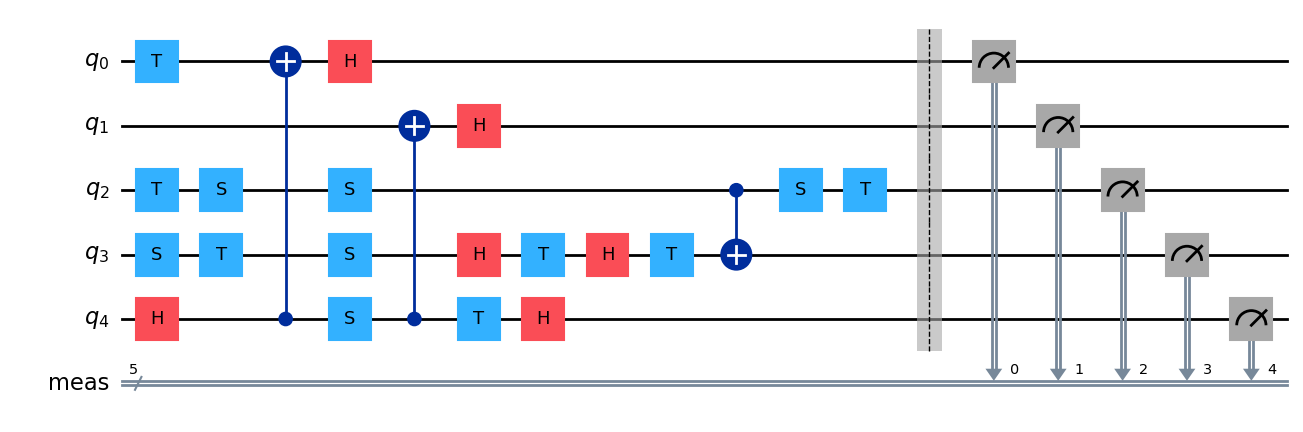

In [70]:
qc.draw("mpl")



In [71]:
from qiskit_aer import AerSimulator

sim_backend = AerSimulator(
    noise_model=noise_model,
    basis_gates=noise_model.basis_gates,
)


In [72]:
from qiskit import transpile

tqc = transpile(
    qc,
    backend=sim_backend,
    optimization_level=0,
)


c:\Users\louis\Documents\M2\Quantum-error-prediction\.venv\Lib\site-packages\qiskit_aer\backends\aerbackend.py:306: RuntimeWarning: No gate definition for xslow can be found and is being excluded from the generated target.
  warnings.warn(


In [73]:
shots = 8192

job_noisy = sim_backend.run(tqc, shots=shots)
result_noisy = job_noisy.result()
counts_noisy = result_noisy.get_counts()

ideal_backend = AerSimulator()
job_ideal = ideal_backend.run(tqc, shots=shots)
counts_ideal = job_ideal.result().get_counts()


In [74]:
def counts_to_probs(counts, shots):
    return {k: v / shots for k, v in counts.items()}

p_noisy = counts_to_probs(counts_noisy, shots)
p_ideal = counts_to_probs(counts_ideal, shots)


In [75]:
assert abs(sum(p_noisy.values()) - 1) < 1e-6
assert abs(sum(p_ideal.values()) - 1) < 1e-6


In [76]:
import numpy as np

def kl_divergence(p, q, eps=1e-12):
    keys = set(p) | set(q)

    kl = 0.0
    for k in keys:
        pk = p.get(k, 0.0)
        qk = q.get(k, 0.0)

        if pk == 0:
            continue

        qk = max(qk, eps)
        kl += pk * np.log(pk / qk)

    return kl

def js_divergence(p, q, eps=1e-12):
    keys = set(p) | set(q)
    js = 0.0

    for k in keys:
        pk = p.get(k, 0.0)
        qk = q.get(k, 0.0)

        if pk == 0.0 and qk == 0.0:
            continue

        mk = 0.5 * (pk + qk)
        mk = max(mk, eps)

        if pk > 0.0:
            js += pk * np.log(pk / mk)

        if qk > 0.0:
            js += qk * np.log(qk / mk)

    return 0.5 * js


kl = kl_divergence(p_noisy, p_ideal)
print("KL(noisy || ideal) =", kl)

js = js_divergence(p_noisy, p_ideal)
print("JS(noisy || ideal) =", js)


KL(noisy || ideal) = 0.4185177681782659
JS(noisy || ideal) = 0.013670954661162993


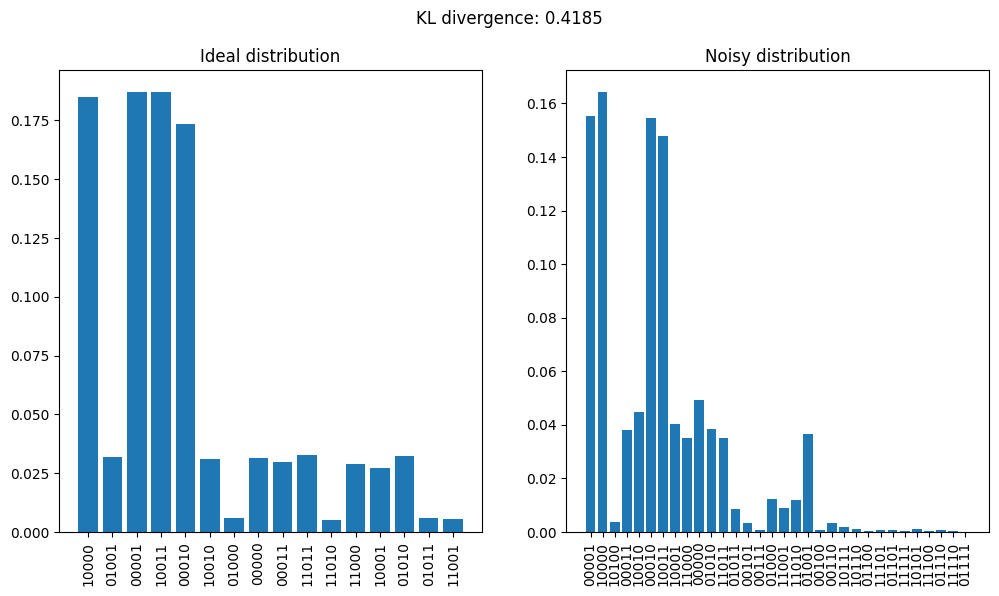

In [77]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].bar(range(len(p_ideal)), list(p_ideal.values()), align='center')
axes[0].set_xticks(range(len(p_ideal)), list(p_ideal.keys()), rotation=90)
axes[0].set_title("Ideal distribution")
axes[1].bar(range(len(p_noisy)), list(p_noisy.values()), align='center')
axes[1].set_xticks(range(len(p_noisy)), list(p_noisy.keys()), rotation=90)
axes[1].set_title("Noisy distribution")
plt.suptitle(f"KL divergence: {kl:.4f}")

plt.show()

In [78]:
# Gate map: key = (gate, tuple(qubits)), value = (gate_error, gate_length)
def extract_gate_map(snapshot_gate):
    return {
        (row.gate, tuple(row.qubits)): (float(row.gate_error), float(row.gate_length))
        for _, row in snapshot_gate.iterrows()
    }

# Qubit map: key = qubit index, value = (prob_meas0_prep1, prob_meas1_prep0, T1, T2, readout_length)
def extract_qubit_map(snapshot_qubit):
    return {
        int(row.qubit): (
            float(row.prob_meas0_prep1),
            float(row.prob_meas1_prep0),
            #float(row.readout_error),
            float(row.T1),
            float(row.T2),
            float(row.readout_length)
        )
        for _, row in snapshot_qubit.iterrows()
    }

In [79]:
from tqdm import tqdm
from time import perf_counter
from collections import defaultdict

def generate_dataset(
    df_qubit,
    df_gate,
    n_samples=1000,
    n_qubits=5,
    max_gates=10,
    backends=["ibm_fez", "ibm_torino", "ibm_marrakesh"],
    shots=8192,
    timeit=False
):
    data = []
    basis = ["id", "rz", "sx", "x", "cx"]
    ideal_backend = AerSimulator()

    timings = defaultdict(float)

    for backend in backends:
        t = perf_counter()

        timestamps = sample_timestamp(n_samples=n_samples).sort_values()
        snapshots_qubit, snapshots_gate, n_utils = snapshot_qubits(df_qubit, df_gate, timestamps, backend)
        print(len(snapshots_qubit), len(snapshots_gate), len(n_utils))
        timings["snapshot"] += perf_counter() - t
        t = perf_counter()

        for snapshot_qubit, snapshot_gate, n_util, timestamp in tqdm(zip(snapshots_qubit, snapshots_gate, n_utils, timestamps), total=n_samples):
            
            if snapshot_gate.empty or snapshot_qubit.empty:
                continue
            
            # backend properties
            backend_props = create_backend_properties(
                snapshot_qubit, snapshot_gate, timestamp, backend
            )
            timings["backend_properties"] += perf_counter() - t
            t = perf_counter()

            # noise model
            noise_model = NoiseModel.from_backend_properties(
                backend_props,
                thermal_relaxation=True
            )

            sim_backend = AerSimulator(
                noise_model=noise_model,
                basis_gates=basis,
            )
            timings["noise_model"] += perf_counter() - t
            t = perf_counter()

            for _ in range(n_util):

                # timestamp + snapshot
                
                #while snapshot_gate.empty or snapshot_qubit.empty:
                #    timestamp = sample_timestamp()
                #    snapshot_gate = snapshot_qubits(df_gate, timestamp, backend)
                #    snapshot_qubit = snapshot_qubits(df_qubit, timestamp, backend)

                

                

                # circuit generation
                qc, n_type_gates = generate_random_circuit(
                    n_qubits=n_qubits,
                    max_gates=max_gates
                )
                timings["circuit_generation"] += perf_counter() - t
                t = perf_counter()

                # transpilation
                tqc = transpile(
                    qc,
                    backend=sim_backend,
                    optimization_level=0
                )
                timings["transpile"] += perf_counter() - t
                t = perf_counter()

                # noisy simulation
                counts_noisy = sim_backend.run(tqc, shots=shots).result().get_counts()
                timings["noisy_simulation"] += perf_counter() - t
                t = perf_counter()

                # ideal simulation
                counts_ideal = ideal_backend.run(tqc, shots=shots).result().get_counts()
                timings["ideal_simulation"] += perf_counter() - t
                t = perf_counter()

                # divergence calculations
                p_noisy = counts_to_probs(counts_noisy, shots)
                p_ideal = counts_to_probs(counts_ideal, shots)
                kl = kl_divergence(p_noisy, p_ideal)
                js = js_divergence(p_noisy, p_ideal)
                timings["divergence"] += perf_counter() - t

                sample = {
                    "backend": backend,
                    "timestamp": timestamp,
                    "n_qubits": n_qubits,
                    "logical_n_gates": sum(n_type_gates.values()),
                    "logical_n_type_gates": n_type_gates,
                    "logical_depth": qc.depth(),
                    "physical_n_gates": tqc.size(),
                    "physical_n_type_gates": tqc.count_ops(),
                    "physical_depth": tqc.depth(),
                    "p_noisy": p_noisy,
                    "p_ideal": p_ideal,
                    "kl_divergence": kl,
                    "js_divergence": js,
                    "gate_props": snapshot_gate[
                        ["entity", "gate", "arity", "gate_error", "gate_length"]
                    ].set_index('entity').to_dict(),
                    "qubit_props": snapshot_qubit[
                        ["entity", "T1", "T2", "readout_error",
                        "prob_meas0_prep1", "prob_meas1_prep0",
                        "readout_length"]
                    ].set_index('entity').to_dict()
                }

                data.append(sample)

    if timeit:
        total = sum(timings.values())
        print("\nTiming summary:")
        for k, v in sorted(timings.items(), key=lambda x: x[1], reverse=True):
            print(f"{k:20s}: {v:.2f}s ({100*v/total:.1f}%)")

    return data

In [82]:
df = pd.DataFrame(generate_dataset(df_qubit,df_gate,n_samples=1000, n_qubits=5, max_gates=10, timeit=True))

df.to_json(
    "3000_thermal_relaxation_dataset.json",
    orient="records",
    indent=2
)

356 356 355


 36%|███▌      | 355/1000 [2:47:09<5:03:42, 28.25s/it] 


341 341 340


 34%|███▍      | 340/1000 [8:21:06<16:12:43, 88.43s/it]   


356 356 355


 36%|███▌      | 355/1000 [3:20:05<6:03:33, 33.82s/it]  



Timing summary:
noise_model         : 33650.81s (64.3%)
noisy_simulation    : 17786.63s (34.0%)
backend_properties  : 358.29s (0.7%)
transpile           : 214.49s (0.4%)
snapshot            : 201.34s (0.4%)
ideal_simulation    : 58.79s (0.1%)
circuit_generation  : 38.00s (0.1%)
divergence          : 1.07s (0.0%)
